# Searching for Correlates in fMRI Data — Circular Analysis ("Double Dipping")

This notebook is a Python translation of `Version1SampleSolution.m`.

## Motivation

The purpose of this exercise is to explore how a data-analysis *workflow* can influence
the validity of a study, and to show how simulations can be used to validate an analysis
workflow **before** applying it to real data — or even before collecting data.

We use an example from cognitive neuroscience. In many studies, researchers search for
brain regions whose activity (in some task) is correlated with a behavioural or
psychological measure. A common workflow is:

1. Identify the brain regions whose activity correlates with the psychological measure.
2. Average the activity in those identified regions.
3. Test how well this aggregate "brain network activity" score correlates with the trait.

We simulate this experiment and analysis in two cases:

- **Question 1 — ground truth is *no effect*** (brain activity is unrelated to the test score).
- **Question 2 — ground truth is a *real effect*** (the test score genuinely modulates brain activity).

The key lesson: selecting voxels by their correlation with the score and then re-testing
that same correlation on the selected voxels produces a spurious "significant" result even
when there is no real effect.

**Dependencies:** `numpy`, `matplotlib`, `scipy` (only for statistics).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set a seed so the notebook is reproducible (remove for fresh random draws)
rng = np.random.default_rng(0)

## Helper: column-wise correlation (equivalent to MATLAB `corr`)

MATLAB's `[r, p] = corr(DA, T)` returns, for each column (voxel) of `DA`, the Pearson
correlation `r` with the vector `T` and its two-tailed p-value `p`. We replicate that
in a vectorized way.

In [2]:
def corr_columns(X, y):
    """Pearson correlation of each column of X (n x p) with vector y (n,).

    Returns (r, p) each of length p, matching MATLAB's corr(X, y).
    """
    y = np.asarray(y, dtype=float).ravel()
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    Xc = X - X.mean(axis=0)
    yc = y - y.mean()
    denom = np.sqrt((Xc ** 2).sum(axis=0) * (yc ** 2).sum())
    with np.errstate(divide="ignore", invalid="ignore"):
        r = (Xc * yc[:, None]).sum(axis=0) / denom
    r = np.clip(r, -1.0, 1.0)
    df = n - 2
    with np.errstate(divide="ignore", invalid="ignore"):
        t = r * np.sqrt(df / (1 - r ** 2))
    p = 2 * stats.t.sf(np.abs(t), df)
    return r, p


def bestfit_line(ax, x, y):
    """Plot the least-squares best fit line (equivalent to MATLAB lsline)."""
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()
    b, a = np.polyfit(x, y, 1)  # slope, intercept
    xl = np.array(ax.get_xlim())
    ax.plot(xl, b * xl + a, "-", color="tab:orange")
    ax.set_xlim(xl)

# Preparations

Suppose we tested `Nsubj = 12` subjects in a study involving a psychological test and a
brain scan.

## Subjects and psychology test scores

First, for each subject we perform a psychological test for some personality trait, giving
a score $T$. To simulate this, we draw a score for each subject at random from a normal
distribution with mean $\mu_T = 50$ and standard deviation $\sigma_T = 10$.

(Making $T$ an integer is not required by the instructions — it just mimics a realistic
test score.)


In [3]:
Nsubj = 12
mT, sT = 50, 10
T = sT * rng.standard_normal(Nsubj) + mT
T = np.round(T)  # not required, but make the score an integer
T

array([51., 49., 56., 51., 45., 54., 63., 59., 43., 37., 44., 50.])

## Simulating the fMRI brain scan (voxel setup)

For each subject we simulate an fMRI brain scan measuring the increase in brain activity
(BOLD signal) in a test condition relative to a control condition — the *differential
activity*. This is measured separately in each of `Nvox = 5000` voxels (cubic volumes in
the brain). For simplicity we assume we can find the corresponding voxels in all 12 brains
and that the same voxels are modulated by the task in every subject. Although real data
would be a 3D volume, we keep the voxels in a 1D vector.

We simulate that **10% of the voxels really are affected** by the task condition
("task-dependent" voxels), drawn from a normal distribution with $\mu_A = 1$, $\sigma_A = 1$.
The remaining voxels have no difference in activity on average ("task-independent" voxels),
drawn from a normal distribution with $\mu_B = 0$, $\sigma_B = \sigma_A$.

**Here's the key point:** although the differential activity really is related to the task
done in the scanner (some voxels genuinely light up), in Question 1 that activity is
*completely unrelated to the psychological test in any voxel*. Let's see how often we would
be fooled into thinking the brain activity and test scores are related, when we know they
are not.


In [4]:
Nvox = 5000
Naffected = round(0.1 * Nvox)
TaskDependentVoxels = np.arange(0, Naffected)
TaskIndependentVoxels = np.arange(Naffected, Nvox)

# Question 1 — Standard analysis method, **no real effect**

We replicate a common data-analysis workflow to identify brain areas whose activity
correlates with a psychology test result:

1. **Correlate each voxel with the test score.** For each of the `Nvox` voxels, take the
   12 subjects' differential-activity values and the 12 subjects' test scores $T$ and test
   whether they are correlated. This gives `Nvox` $r$ values and $p$ values.
2. **Define the "Modulated" voxels** as all voxels *positively* correlated with $T$ under
   the criteria $r > 0.1$ **and** $p < 0.05$. (These may or may not be task-dependent voxels.)
3. **Average within each subject** the differential activity of the modulated voxels to get a
   single "Relevant Brain Network Activity" (RBNA) value per subject.
4. **Scatter plot** RBNA versus test score $T$ (1 symbol per subject, 12 subjects).
5. **Fit a line** and label the plot with the $R^2$ and $p$ values (done in the plotting cell below).

First, simulate the null data set. Task-dependent voxels are drawn with mean `mA`, std `sA`;
task-independent voxels with mean 0, std `sA`. Crucially, the voxel activity does **not**
depend on `T`, so there is no true relationship between brain activity and the score.


In [5]:
mA, sA = 1, 1
DA = np.empty((Nsubj, Nvox))
DA[:, TaskDependentVoxels] = sA * rng.standard_normal((Nsubj, Naffected)) + mA
DA[:, TaskIndependentVoxels] = sA * rng.standard_normal((Nsubj, Nvox - Naffected))

In [6]:
# 1. Correlate each voxel's differential activity with the psychology score.
r, p = corr_columns(DA, T)

# 2. "Relevant" voxels: positive correlation r > 0.1 AND significant p < 0.05.
ModulatedVoxels = np.where((r > 0.1) & (p < 0.05))[0]

# 3. Average the differential activity of the relevant voxels within each subject.
RBNA = DA[:, ModulatedVoxels].mean(axis=1)
print(f"Number of 'relevant' voxels selected: {ModulatedVoxels.size}")
print(f"RBNA shape (should be {Nsubj}): {RBNA.shape}")

Number of 'relevant' voxels selected: 113
RBNA shape (should be 12): (12,)


# Question 2 — Standard analysis method, **with a real effect**

Now we repeat the entire simulation, but this time the psychology test really *does* predict
how strongly the scanner task modulates brain activity in the task-dependent voxels. Instead
of using a fixed mean $\mu_A$ for the task-dependent voxels, we use $\mu_A(i) = f(T(i))$, a
function of each subject's score.

We contrive $f$ so that the **average** value of $\mu_A(i)$ is the same as the fixed $\mu_A$
used in the null simulation (so overall activity levels match), while $\mu_A(i)$ is
*noticeably but only modestly* correlated with $T(i)$. Concretely we use a scaled, shifted
version of $T$:

$$T_\text{scaled} = \frac{k\, \sigma_A}{\operatorname{std}(T)}\,(T - \overline{T}) + \mu_A$$

The constant `k` sets how big the trait effect is relative to noise:
`k=1` → the task-related signal is mostly determined by the trait; `k=0.1` → the trait only
weakly affects it. Here `k=0.2` gives a modest correlation. Then the rest of the analysis
workflow is applied exactly as in Question 1.


In [7]:
k = 0.2  # modest correlation between task-related signal and trait
Tscaled = (k * sA / np.std(T, ddof=1)) * (T - np.mean(T)) + mA

DA_real = np.empty((Nsubj, Nvox))
for i in range(Nsubj):
    DA_real[i, TaskDependentVoxels] = (
        sA * rng.standard_normal(Naffected) + Tscaled[i]
    )
DA_real[:, TaskIndependentVoxels] = sA * rng.standard_normal((Nsubj, Nvox - Naffected))

r2, p2 = corr_columns(DA_real, T)
ModulatedVoxels_real = np.where((r2 > 0.1) & (p2 < 0.05))[0]
RBNA_real = DA_real[:, ModulatedVoxels_real].mean(axis=1)
print(f"Number of 'relevant' voxels selected: {ModulatedVoxels_real.size}")

Number of 'relevant' voxels selected: 153


## Plot both cases

For each subject, plot Relevant Brain Network Activity (RBNA) vs. their psychology
test score, with the best-fit line and the $R^2$ / p-value of the (circular)
correlation. Note that even the "no real effect" case tends to look significant —
that is the double-dipping artifact.

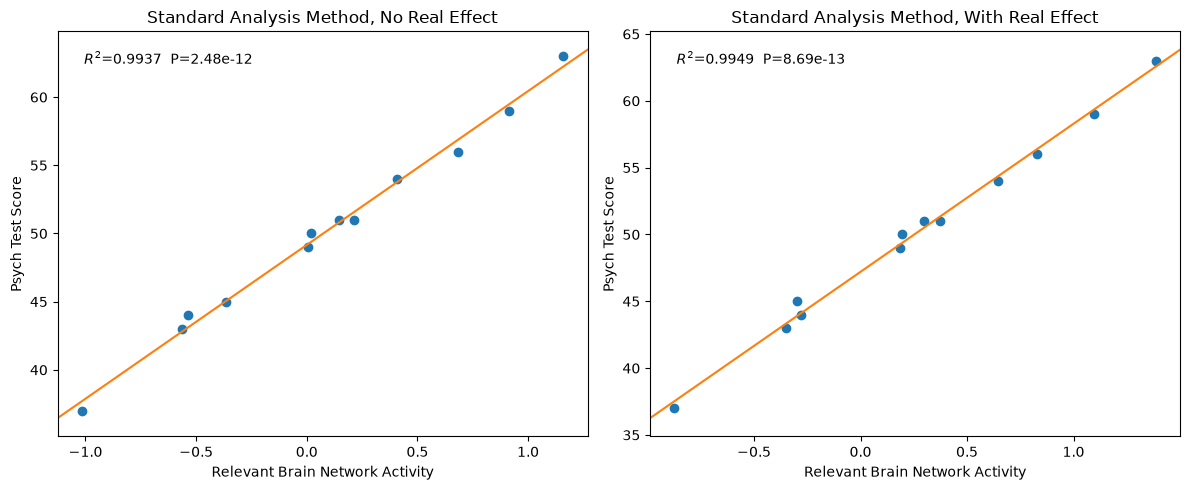

In [8]:
def annotate_corr(ax, rbna, T, title):
    ax.plot(rbna, T, "o", color="tab:blue", markerfacecolor="tab:blue")
    bestfit_line(ax, rbna, T)
    ax.set_xlabel("Relevant Brain Network Activity")
    ax.set_ylabel("Psych Test Score")
    ax.set_title(title)
    r_model, p_model = stats.pearsonr(rbna, T)
    Rsquared = r_model ** 2
    xlims, ylims = ax.get_xlim(), ax.get_ylim()
    xpos = xlims[0] + 0.05 * (xlims[1] - xlims[0])
    ypos = ylims[1] - 0.08 * (ylims[1] - ylims[0])
    ax.text(xpos, ypos, f"$R^2$={Rsquared:.4f}  P={p_model:.2e}")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
annotate_corr(axes[0], RBNA, T, "Standard Analysis Method, No Real Effect")
annotate_corr(axes[1], RBNA_real, T, "Standard Analysis Method, With Real Effect")
plt.tight_layout()
plt.show()

## What to think about (interpreting the two plots)

Compare the two panels. In the **left** panel (no real effect) the ground truth is that
brain activity is completely unrelated to the psychology test — yet the scatter typically
shows a convincing-looking positive trend with a high $R^2$ and a small $p$ value. This is a
**false positive**. In the **right** panel (real effect) we see a similar-looking trend.

The uncomfortable observation: the false positive from the null simulation looks about as
convincing — in $R^2$, $p$ value, and scatter plot — as the true positive. On the strength of
these plots alone you generally *cannot* tell a false positive from a real effect.

*(Optional extension, per step 6 of the assignment: wrap the Question 1 simulation in a loop
that draws a fresh random null data set 1,000–10,000 times, and count what fraction of runs
produce a "significant" result, e.g. $p < 0.01$. You would find the false-positive rate is far
above the nominal 1%.)*

## Question 3 — What is wrong with this workflow?

The flaw is **circular analysis**, also called **"double dipping"** or non-independence
error. The *same* 12 subjects' data are used twice:

1. First to **select** the voxels — we keep exactly those voxels that happen to correlate
   positively with $T$ in this particular sample.
2. Then to **test** the correlation — we re-measure the correlation between $T$ and the average
   of those hand-picked voxels.

Because the selection step cherry-picks voxels whose *noise* happens to align with $T$, the
averaged network is guaranteed to correlate with $T$ in the same sample even when no true
relationship exists. The final correlation test is therefore not valid: its null distribution
is not the standard one, so the reported $p$ value is meaningless.

**A better (independent) workflow** — split the data so that selection and testing use
different observations. For example:

- **Cross-validation / data splitting:** select the "modulated" voxels using one subset of
  subjects (or scan runs), then compute RBNA and test its correlation with $T$ on a *held-out*
  subset that played no part in selection.
- **A fully independent localizer:** define the voxel set from separate data (e.g. an
  independent task-localizer scan), then apply it to the experimental data.

Applied to the null data (Question 1) this independent approach brings the false-positive rate
back down to the nominal level (~1% at $p<0.01$), so spurious correlations largely disappear.
Applied to the real-effect data (Question 2) it still detects the genuine effect — with lower
power than the (invalid) circular method, but with a trustworthy $p$ value.
